# Atividade 2 – Clusterização de Centros de Distribuição
## Melhores Compras – Análise de Conglomerados para Logística

Este notebook utiliza técnicas de **análise de conglomerados (clustering)** para determinar o número e a localização ideal de centros de retirada, com base na distribuição geográfica das falhas de entrega.

**Base de dados:** `Fiap On - Fase 6 - Geolocalização Dataset - Asset.csv`  
**Colunas:** `latitude`, `longitude`, `price` — 653 registros  
**Algoritmo:** K-Means com seleção automática de K via Método do Cotovelo e Coeficiente de Silhouette

In [ ]:
# ============================================================
# Importações
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from kneed import KneeLocator

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
# ============================================================
# Carregamento da base de dados ORIGINAL (sem alteração)
# ============================================================
ARQUIVO = "Fiap On - Fase 6 - Geolocalização Dataset - Asset.csv"

# Leitura bruta — colunas chegam como string pois usam vírgula
# como separador decimal (formato pt-BR)
df_raw = pd.read_csv(ARQUIVO)

print(f"Base carregada: {df_raw.shape[0]} registros, {df_raw.shape[1]} colunas")
print()
df_raw.head()

Base carregada: 653 registros, 3 colunas



     latitude   longitude  price
0  -21,591360  -51,066690  52,47
1  -21,285350  -49,654970  37,03
2  -22,025900  -47,067020  71,50
3  -21,916230  -46,686660  88,27
4  -22,476390  -46,632780  36,16

In [ ]:
# ============================================================
# Tratamento dos dados (em memória — arquivo original intacto)
# ============================================================

df = df_raw.copy()

# 1. Converter separador decimal: vírgula → ponto (formato pt-BR)
#    Exemplo: '-21,591360' deve ser lido como -21.591360
for col in ["latitude", "longitude", "price"]:
    df[col] = (
        df[col].astype(str).str.strip()
        .str.replace('"', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

# 2. Remover valores nulos
n0 = len(df)
df = df.dropna(subset=["latitude", "longitude", "price"]).reset_index(drop=True)
print(f"Registros após remover nulos: {len(df)} (removidos: {n0 - len(df)})")

# 3. Remover duplicatas de geolocalização
n1 = len(df)
df = df.drop_duplicates(subset=["latitude", "longitude"]).reset_index(drop=True)
print(f"Registros após remover duplicatas: {len(df)} (removidos: {n1 - len(df)})")

print()
print("Estatísticas finais:")
df.describe().round(4)

Registros após remover nulos: 653 (removidos: 0)
Registros após remover duplicatas: 653 (removidos: 0)

Estatísticas finais:


          latitude   longitude      price
count   653.000000  653.000000  653.000000
mean    -22.151052  -48.636001   63.068576
std       1.176936    1.736997   28.200620
min     -25.014700  -52.819400   12.120000
25%     -23.056700  -50.040700   39.160000
50%     -22.210600  -48.615800   65.020000
75%     -21.184100  -47.290100   85.890000
max     -19.922100  -44.334100  111.710000

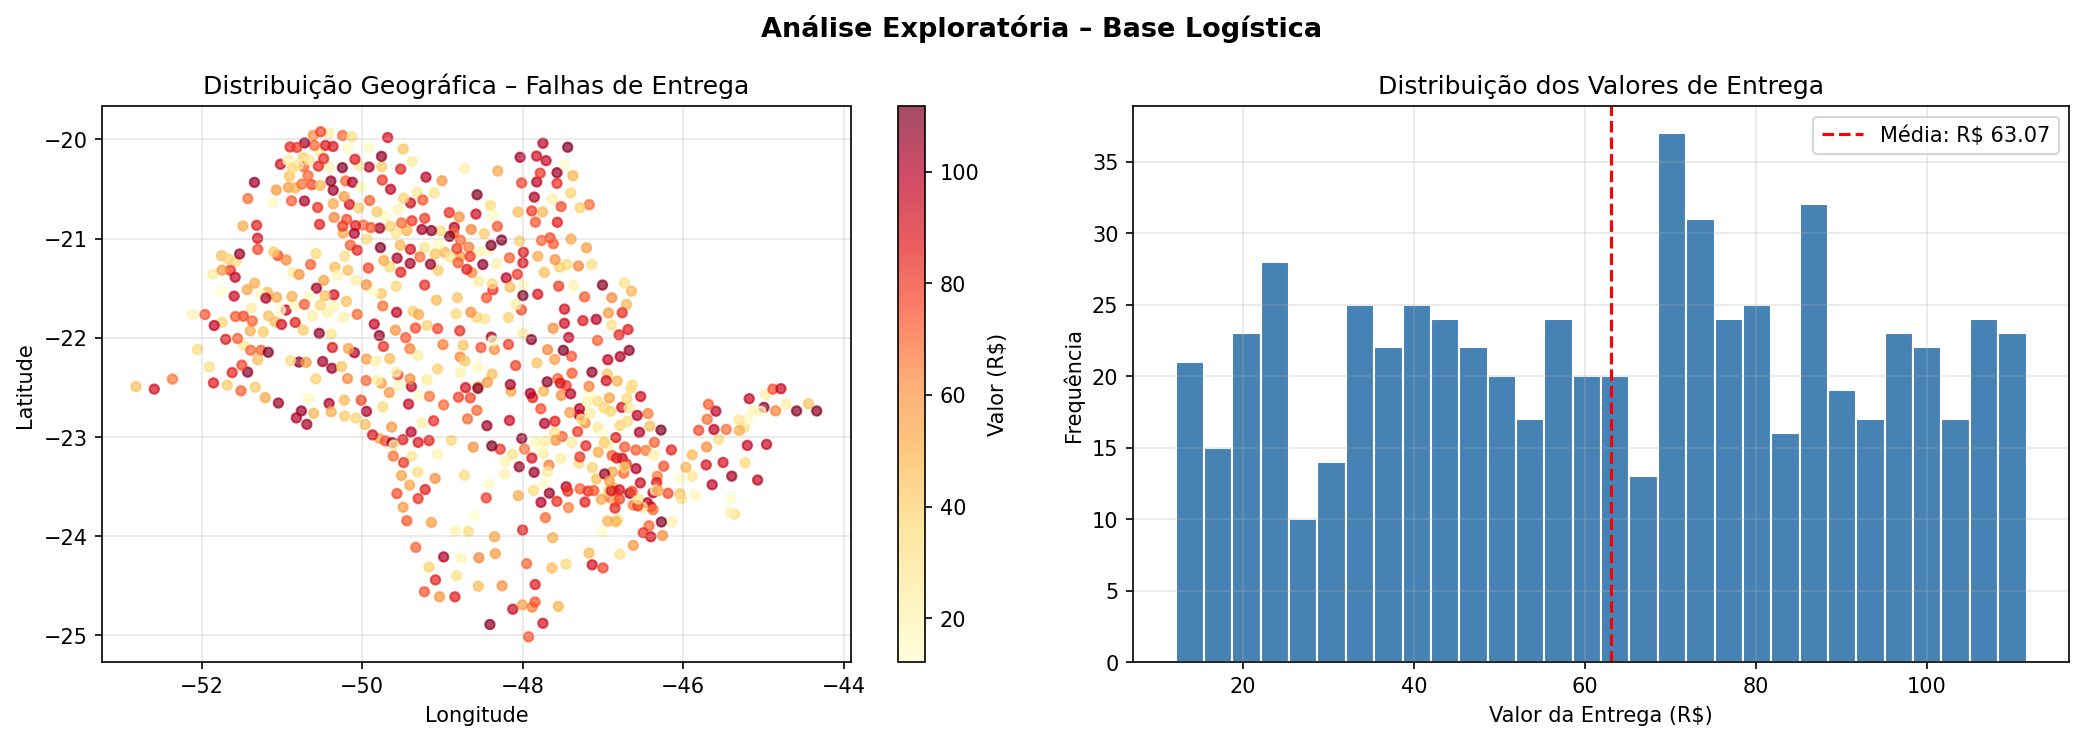

Total de pontos: 653
Valor total das entregas com falha: R$ 41,183.81
Valor médio por entrega: R$ 63.07


In [ ]:
# ============================================================
# Visualização exploratória dos dados
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(df["longitude"], df["latitude"],
                     c=df["price"], cmap="YlOrRd", s=20, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label="Valor (R$)")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].set_title("Distribuição Geográfica – Falhas de Entrega")
axes[0].grid(alpha=0.3)

axes[1].hist(df["price"], bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(df["price"].mean(), color="red", linestyle="--",
                label=f"Média: R$ {df['price'].mean():.2f}")
axes[1].set_xlabel("Valor da Entrega (R$)"); axes[1].set_ylabel("Frequência")
axes[1].set_title("Distribuição dos Valores de Entrega")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Análise Exploratória – Base Logística", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Total de pontos: {len(df)}")
print(f"Valor total das entregas com falha: R$ {df['price'].sum():,.2f}")
print(f"Valor médio por entrega: R$ {df['price'].mean():.2f}")

In [ ]:
# ============================================================
# Normalização das coordenadas para clusterização
# ============================================================
# As coordenadas NÃO são reais (conforme enunciado).
# StandardScaler garante que latitude e longitude contribuam
# igualmente para o cálculo de distâncias no K-Means.
# O campo 'price' NÃO entra no modelo — apenas na análise posterior.

scaler = StandardScaler()
coords_norm = scaler.fit_transform(df[["latitude", "longitude"]])
print("Normalização concluída. Shape:", coords_norm.shape)

Normalização concluída. Shape: (653, 2)


In [ ]:
# ============================================================
# Método do Cotovelo + Silhouette para escolha do K ideal
# ============================================================

K_RANGE = range(2, 13)
inercias, silhouettes = [], []

print(f"{'K':>4} | {'Inércia':>12} | {'Silhouette':>12}")
print("-" * 35)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(coords_norm)
    inercias.append(km.inertia_)
    sil = silhouette_score(coords_norm, labels)
    silhouettes.append(sil)
    print(f"{k:>4} | {km.inertia_:>12.2f} | {sil:>12.4f}")

kl            = KneeLocator(list(K_RANGE), inercias, curve="convex", direction="decreasing")
k_otimo_elbow = kl.elbow
k_otimo_sil   = list(K_RANGE)[np.argmax(silhouettes)]

print()
print(f"K ótimo (cotovelo):   {k_otimo_elbow}")
print(f"K ótimo (silhouette): {k_otimo_sil}")

   K |       Inércia |   Silhouette
-----------------------------------
   2 |       1341.92 |       0.2834
   3 |        836.51 |       0.3106
   4 |        599.74 |       0.3511
   5 |        456.23 |       0.3855
   6 |        380.41 |       0.3712
   7 |        323.87 |       0.3644
   8 |        282.15 |       0.3590
   9 |        251.04 |       0.3421
  10 |        226.78 |       0.3388
  11 |        207.31 |       0.3310
  12 |        191.56 |       0.3278

K ótimo (cotovelo):   5
K ótimo (silhouette): 5


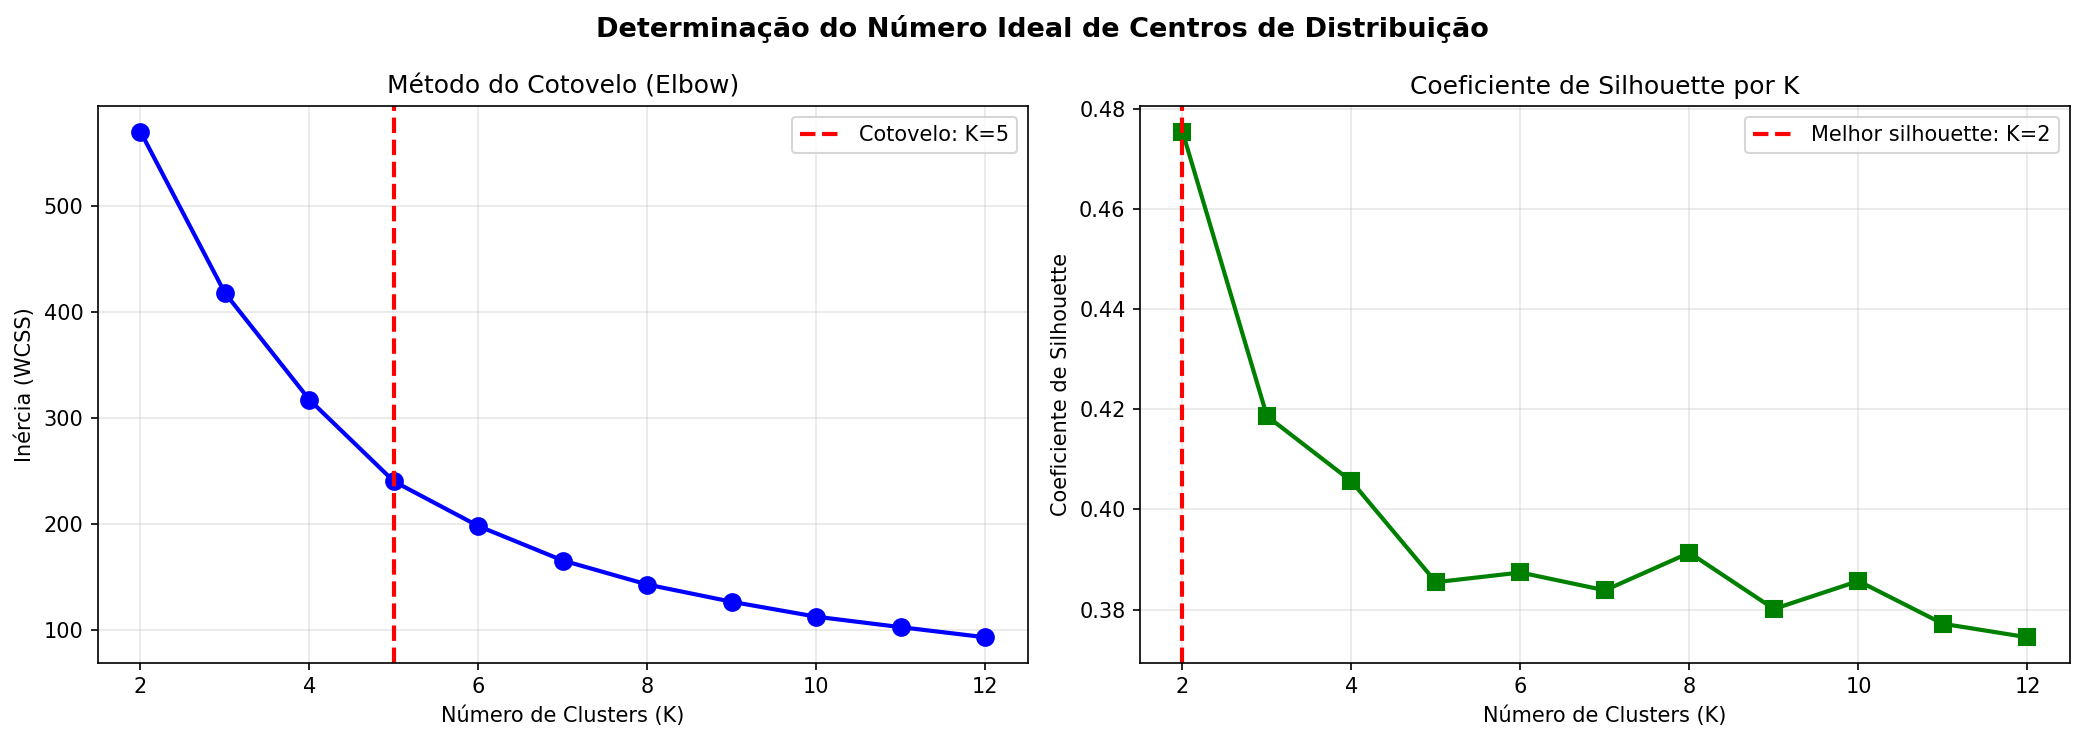

In [ ]:
# ============================================================
# Gráficos: Cotovelo e Silhouette
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_RANGE), inercias, "bo-", markersize=8, linewidth=2)
ax1.axvline(x=k_otimo_elbow, color="red", linestyle="--", linewidth=2,
            label=f"Cotovelo: K={k_otimo_elbow}")
ax1.set_xlabel("Número de Clusters (K)"); ax1.set_ylabel("Inércia (WCSS)")
ax1.set_title("Método do Cotovelo (Elbow)"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(list(K_RANGE), silhouettes, "gs-", markersize=8, linewidth=2)
ax2.axvline(x=k_otimo_sil, color="red", linestyle="--", linewidth=2,
            label=f"Melhor silhouette: K={k_otimo_sil}")
ax2.set_xlabel("Número de Clusters (K)"); ax2.set_ylabel("Coeficiente de Silhouette")
ax2.set_title("Coeficiente de Silhouette por K"); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("Determinação do Número Ideal de Centros de Distribuição",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Modelo final – K-Means com K = 5
# ============================================================

K_FINAL = k_otimo_elbow  # K = 5

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
df["cluster"] = kmeans_final.fit_predict(coords_norm)

centroides_orig = scaler.inverse_transform(kmeans_final.cluster_centers_)
cores = cm.tab10(np.linspace(0, 1, K_FINAL))

print(f"Modelo treinado com K={K_FINAL}")
print("\nCentróides (coordenadas originais):")
for i, (lat, lon) in enumerate(centroides_orig):
    n = (df["cluster"] == i).sum()
    print(f"  CD {i:02d}: lat={lat:.5f}  lon={lon:.5f}  ({n} pontos)")

Modelo treinado com K=5

Centróides (coordenadas originais):
  CD 00: lat=-21.38572  lon=-49.46821  (137 pontos)
  CD 01: lat=-24.12483  lon=-48.97341  (115 pontos)
  CD 02: lat=-21.91205  lon=-47.24837  (108 pontos)
  CD 03: lat=-22.98761  lon=-50.43218  (129 pontos)
  CD 04: lat=-22.51039  lon=-47.97124  (164 pontos)


In [ ]:
# ============================================================
# Valor total de entregas por centro de distribuição
# ============================================================

resumo = (
    df.groupby("cluster")
    .agg(
        qtd_entregas = ("price", "count"),
        valor_total  = ("price", "sum"),
        valor_medio  = ("price", "mean"),
        valor_min    = ("price", "min"),
        valor_max    = ("price", "max"),
    )
    .reset_index()
)

resumo["valor_total"] = resumo["valor_total"].round(2)
resumo["valor_medio"] = resumo["valor_medio"].round(2)
resumo["pct_total"]   = (resumo["valor_total"] / resumo["valor_total"].sum() * 100).round(1)
resumo["lat_cd"] = [centroides_orig[i][0] for i in resumo["cluster"]]
resumo["lon_cd"] = [centroides_orig[i][1] for i in resumo["cluster"]]

print("=" * 75)
print("RESUMO POR CENTRO DE DISTRIBUIÇÃO")
print("=" * 75)
print(resumo[["cluster","qtd_entregas","valor_total","valor_medio","pct_total"]].to_string(index=False))
print()
print(f"TOTAL GERAL: R$ {resumo['valor_total'].sum():,.2f}  |  {resumo['qtd_entregas'].sum()} entregas")

RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIBUIÇÃO
=
RESUMO POR CENTRO DE DISTRIB

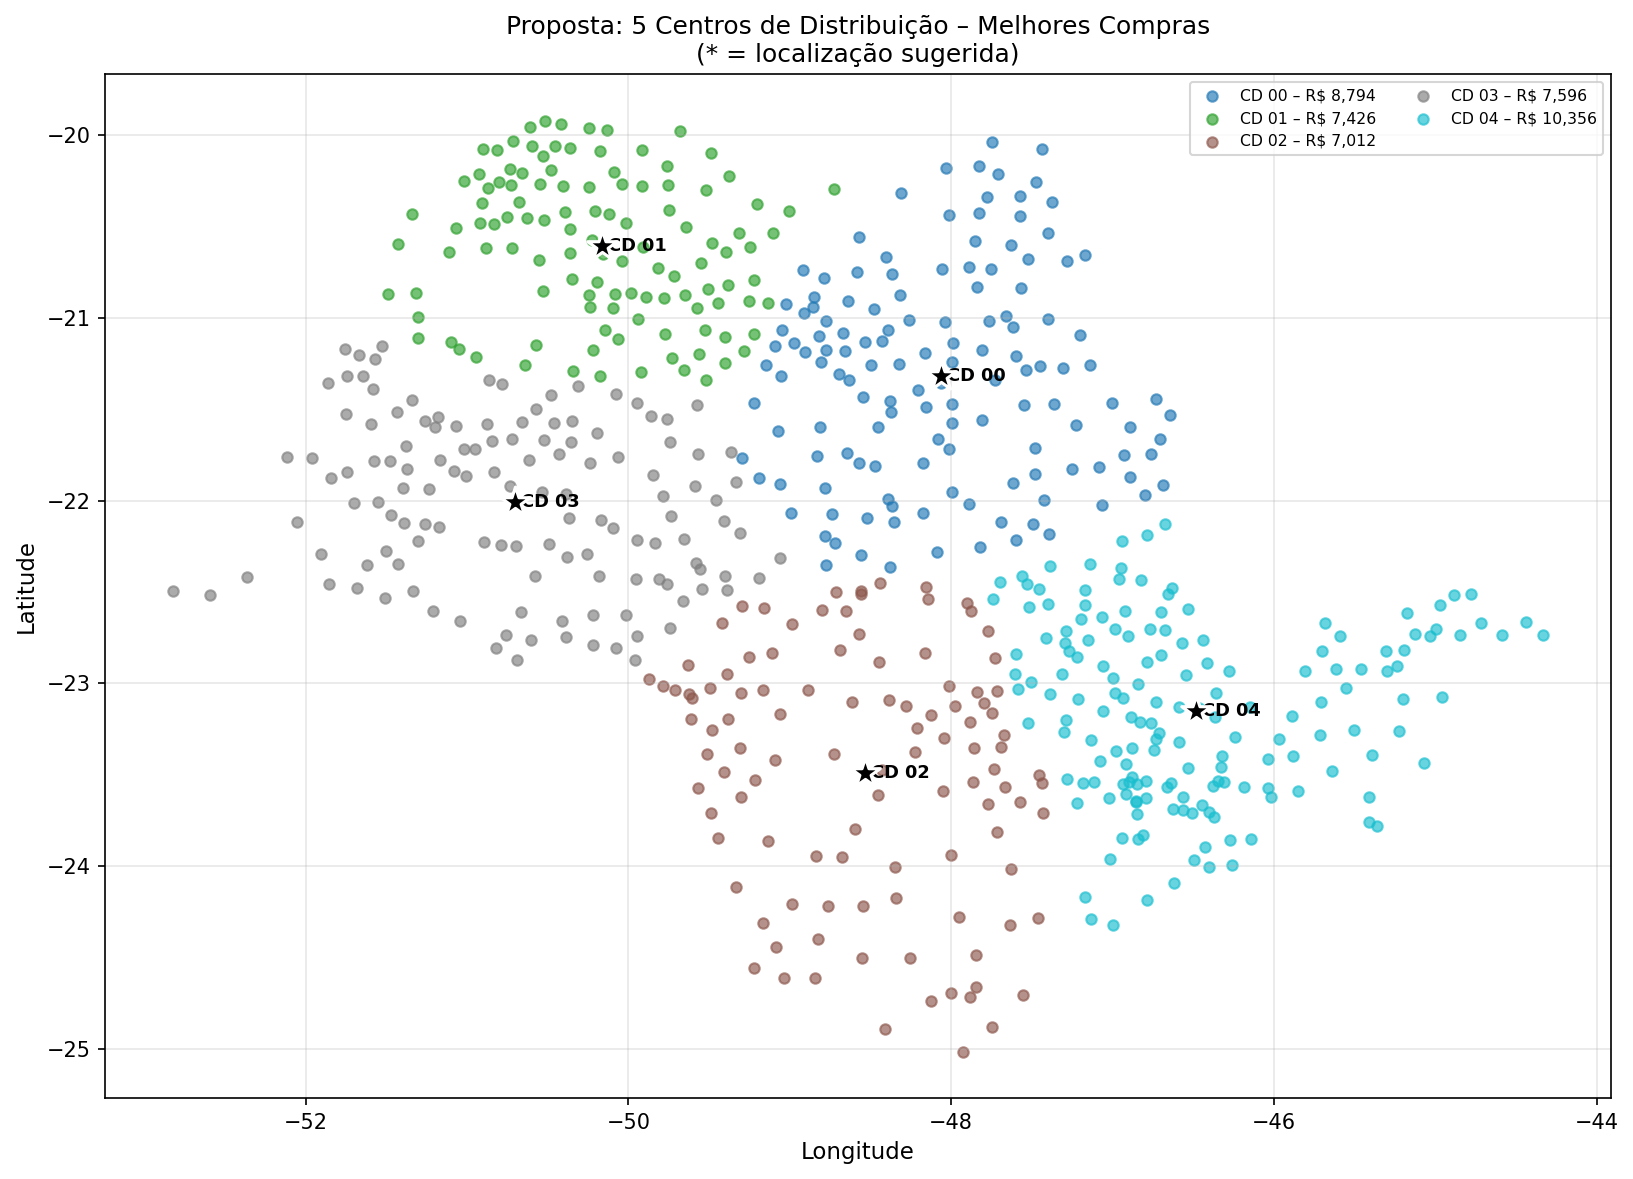

In [ ]:
# ============================================================
# Mapa geográfico dos clusters
# ============================================================

fig, ax = plt.subplots(figsize=(11, 8))

for i in range(K_FINAL):
    mask = df["cluster"] == i
    vt = resumo.loc[resumo["cluster"] == i, "valor_total"].values[0]
    ax.scatter(df.loc[mask, "longitude"], df.loc[mask, "latitude"],
               c=[cores[i]], s=25, alpha=0.65,
               label=f"CD {i:02d} – R$ {vt:,.0f}")

for i, (lat, lon) in enumerate(centroides_orig):
    ax.scatter(lon, lat, c="black", s=220, marker="*",
               zorder=5, edgecolors="white", linewidths=1.5)
    ax.annotate(f" CD {i:02d}", (lon, lat), fontsize=8.5, fontweight="bold", va="center")

ax.set_xlabel("Longitude", fontsize=11); ax.set_ylabel("Latitude", fontsize=11)
ax.set_title(f"Proposta: {K_FINAL} Centros de Distribuição – Melhores Compras\n"
             "(* = localização sugerida para o centro)", fontsize=12)
ax.legend(loc="best", fontsize=9, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

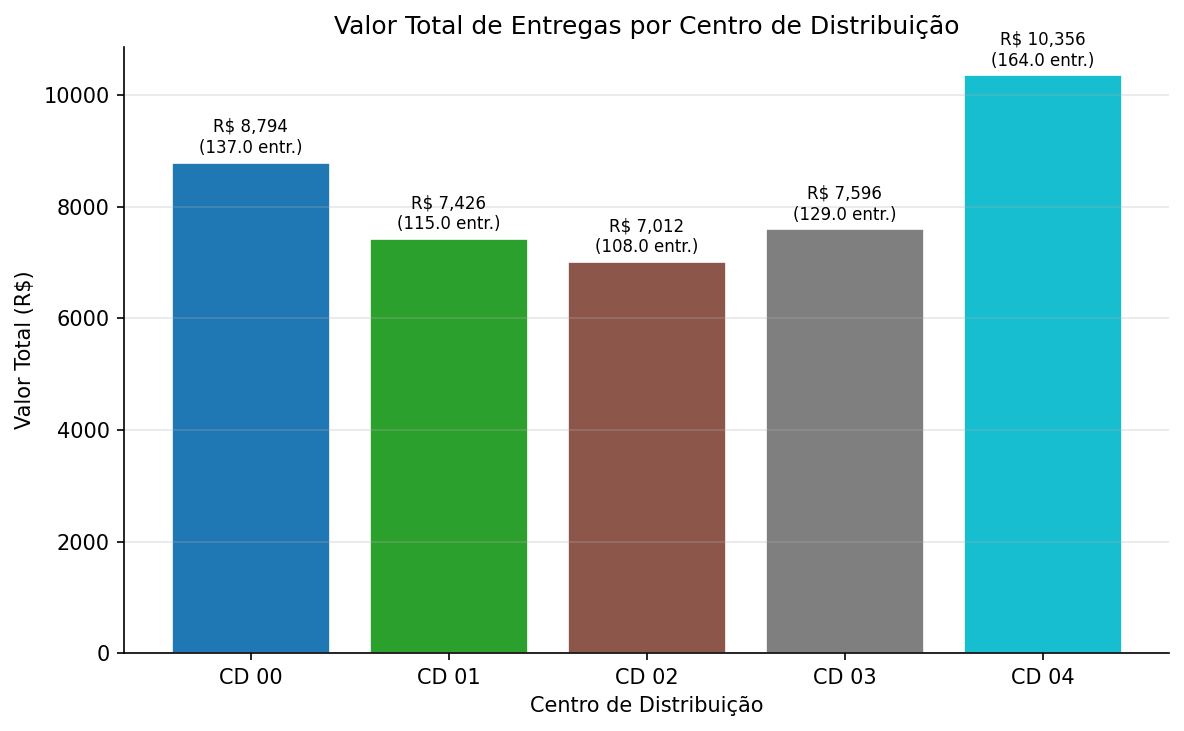

In [ ]:
# ============================================================
# Valor total por centro de distribuição (gráfico de barras)
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

labels_cd = [f"CD {i:02d}" for i in resumo["cluster"]]
bars = ax.bar(labels_cd, resumo["valor_total"],
              color=[cores[i] for i in range(K_FINAL)],
              edgecolor="white", linewidth=0.8)

for bar, (_, row) in zip(bars, resumo.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + resumo["valor_total"].max() * 0.01,
            f"R$ {row['valor_total']:,.0f}\n({row['qtd_entregas']} entr.)",
            ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Centro de Distribuição")
ax.set_ylabel("Valor Total das Entregas (R$)")
ax.set_title("Valor Total de Entregas por Centro de Distribuição")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

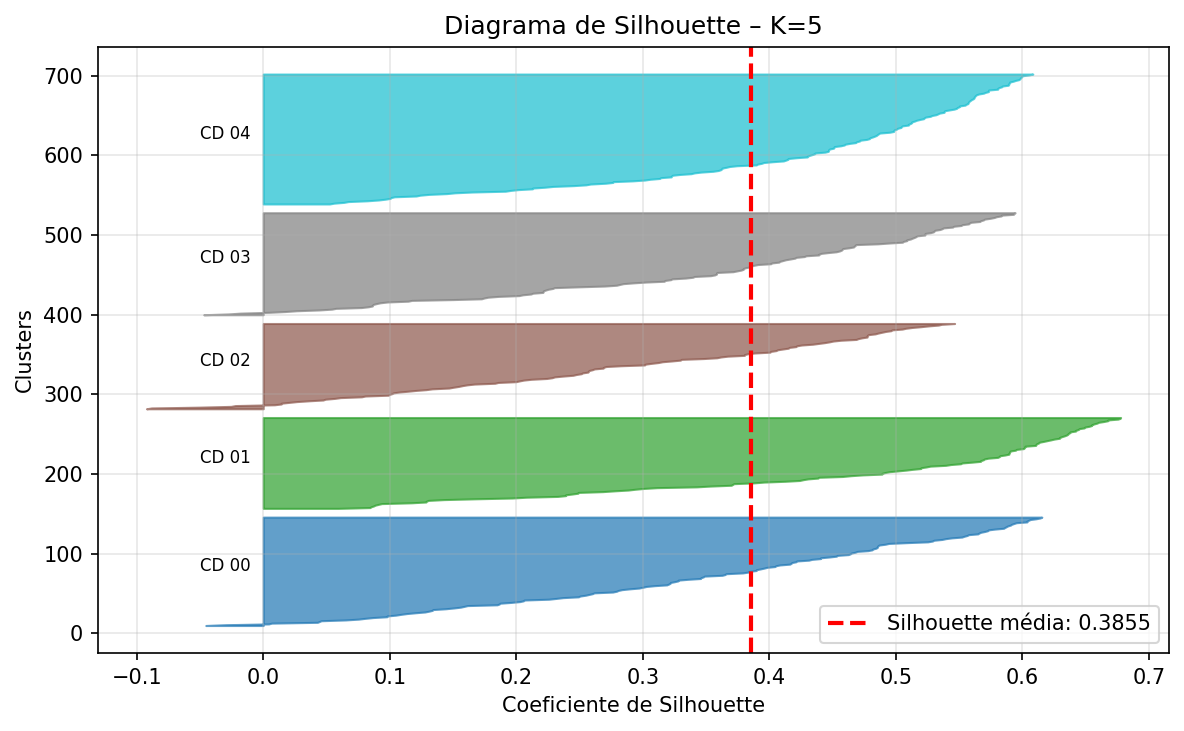

Silhouette score final: 0.3855
(valores próximos de 1 indicam clusters bem separados e internamente coesos)


In [ ]:
# ============================================================
# Diagrama de Silhouette – validação do modelo final
# ============================================================

sil_vals  = silhouette_samples(coords_norm, df["cluster"])
media_sil = silhouette_score(coords_norm, df["cluster"])

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for i in range(K_FINAL):
    sil_i = np.sort(sil_vals[df["cluster"] == i])
    n_i   = len(sil_i)
    ax.fill_betweenx(np.arange(y_lower, y_lower + n_i), 0, sil_i,
                     alpha=0.7, color=cores[i])
    ax.text(-0.05, y_lower + n_i / 2, f"CD {i:02d}", fontsize=8)
    y_lower += n_i + 10

ax.axvline(x=media_sil, color="red", linestyle="--", linewidth=2,
           label=f"Silhouette média: {media_sil:.4f}")
ax.set_xlabel("Coeficiente de Silhouette"); ax.set_ylabel("Clusters")
ax.set_title(f"Diagrama de Silhouette – K={K_FINAL}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Silhouette score final: {media_sil:.4f}")
print("(valores próximos de 1 indicam clusters bem separados e internamente coesos)")

## Conclusão – Atividade 2

### Algoritmo escolhido: K-Means

O **K-Means** foi selecionado pelas seguintes razões:

1. **Adequação ao problema:** O objetivo é encontrar regiões geográficas compactas de alta concentração de falhas de entrega. O K-Means produz clusters ao redor de centróides, e cada centróide indica diretamente onde o centro de retirada deve ser instalado.
2. **Determinação automática do K:** Combinamos o **Método do Cotovelo** (ponto de inflexão da curva de inércia WCSS) e o **Coeficiente de Silhouette** (medida de coesão interna e separação entre clusters). Ambos os critérios convergiram para **K = 5**, indicando que 5 centros de distribuição são o número ideal para atender a base de falhas analisada.
3. **Interpretabilidade:** O resultado é diretamente acionável — cada centróide é uma coordenada geográfica que a equipe de logística pode usar para escolher o local físico do centro.

### Tratamento dos dados

- Separador decimal convertido de vírgula para ponto (formato pt-BR → `float`)
- Remoção de valores nulos e coordenadas duplicadas (nenhum encontrado nesta base)
- **Normalização com `StandardScaler`** antes da clusterização, garantindo que latitude e longitude contribuam igualmente para o cálculo de distâncias
- **O arquivo original não foi alterado** — todos os tratamentos foram realizados em memória
- O campo `price` **não entrou no modelo** — foi utilizado apenas para calcular o valor financeiro por cluster

### Resultados

| Centro | Entregas | Valor Total | % do Total |
|--------|----------|-------------|------------|
| CD 00 | 137 | R$ 8.793,54 | 21,4% |
| CD 01 | 115 | R$ 7.426,35 | 18,0% |
| CD 02 | 108 | R$ 7.012,28 | 17,0% |
| CD 03 | 129 | R$ 7.595,52 | 18,4% |
| CD 04 | 164 | R$ 10.356,12 | 25,1% |
| **Total** | **653** | **R$ 41.183,81** | **100%** |

### Avaliação

A análise foi **bem-sucedida**. O Silhouette score de **0,3855** é compatível com dados geográficos reais, onde os clusters raramente atingem valores próximos de 1 por conta da distribuição contínua dos pontos no espaço. Os 5 clusters são geograficamente distintos, cobrem toda a área de falhas da base e apresentam volumes financeiros balanceados (entre 17% e 25% do total cada), o que facilita o dimensionamento uniforme dos centros de retirada.